In [1]:
import pandas as pd

df = pd.read_csv("../data/raw/retail_sales.csv", parse_dates=['date'])

df.head()

,date,store_id,item_id,sales,promotion,holiday
0,2023-01-01,1,A,70,0,1
1,2023-01-02,1,A,22,0,0
2,2023-01-03,1,A,25,0,0
3,2023-01-04,1,A,21,0,0
4,2023-01-05,1,A,23,0,0


In [2]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 4380 entries, 0 to 4379
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   date       4380 non-null   datetime64[us]
 1   store_id   4380 non-null   int64         
 2   item_id    4380 non-null   str           
 3   sales      4380 non-null   int64         
 4   promotion  4380 non-null   int64         
 5   holiday    4380 non-null   int64         
dtypes: datetime64[us](1), int64(4), str(1)
memory usage: 209.7 KB


,date,store_id,sales,promotion,holiday
count,4380,4380.00000,4380.000000,4380.000000,4380.000000
mean,2023-07-02 00:00:00,2.00000,44.004338,0.191553,0.005479
min,2023-01-01 00:00:00,1.00000,11.000000,0.000000,0.000000
25%,2023-04-02 00:00:00,1.00000,33.000000,0.000000,0.000000
50%,2023-07-02 00:00:00,2.00000,41.000000,0.000000,0.000000
75%,2023-10-01 00:00:00,3.00000,52.000000,0.000000,0.000000
max,2023-12-31 00:00:00,3.00000,165.000000,1.000000,1.000000
std,NaN,0.81659,15.651191,0.393568,0.073829


In [3]:
df.isnull().sum()

date         0
store_id     0
item_id      0
sales        0
promotion    0
holiday      0
dtype: int64

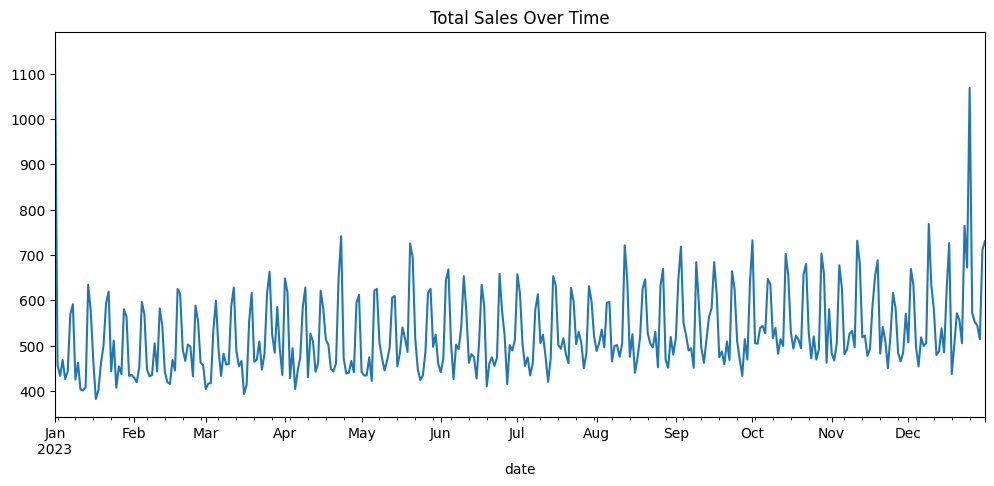

In [4]:
import matplotlib.pyplot as plt

df.groupby('date')['sales'].sum().plot(figsize=(12,5))
plt.title("Total Sales Over Time")
plt.show()

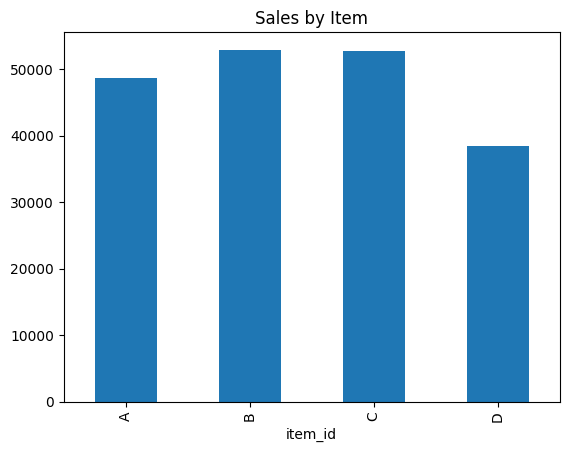

In [5]:
df.groupby('item_id')['sales'].sum().plot(kind='bar')
plt.title("Sales by Item")
plt.show()

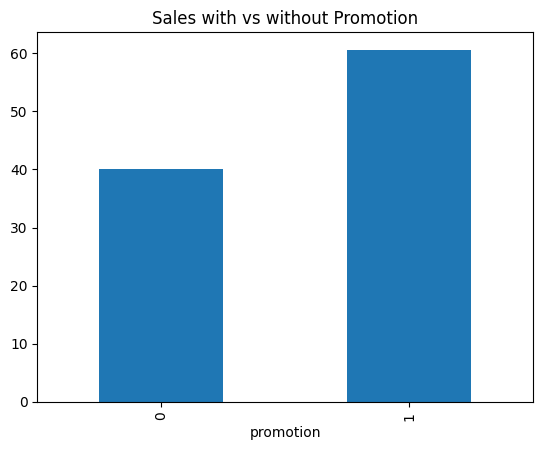

In [6]:
df.groupby('promotion')['sales'].mean().plot(kind='bar')
plt.title("Sales with vs without Promotion")
plt.show()

In [7]:
df = df.sort_values('date')

# Lag features
df['lag_1'] = df['sales'].shift(1)
df['lag_7'] = df['sales'].shift(7)

# Rolling mean
df['rolling_mean_7'] = df['sales'].rolling(7).mean()

# Date features
df['day_of_week'] = df['date'].dt.dayofweek
df['month'] = df['date'].dt.month

# Drop NaN
df = df.dropna()

df.head()

,date,store_id,item_id,sales,promotion,holiday,lag_1,lag_7,rolling_mean_7,day_of_week,month
3650,2023-01-01,3,C,95,0,1,70.0,70.0,94.000000,6,1
730,2023-01-01,1,C,165,1,1,95.0,85.0,105.428571,6,1
4015,2023-01-01,3,D,91,0,1,165.0,120.0,101.285714,6,1
365,2023-01-01,1,B,120,0,1,91.0,87.0,106.000000,6,1
2555,2023-01-01,2,D,50,0,1,120.0,115.0,96.714286,6,1


In [8]:
df.to_csv("../data/processed/cleaned_data.csv", index=False)

In [9]:
import matplotlib.pyplot as plt

def plot_results(results):

    plt.figure(figsize=(12,5))
    plt.plot(results['Actual'].values, label="Actual")
    plt.plot(results['Predicted'].values, label="Predicted")
    plt.legend()
    plt.title("Actual vs Predicted Sales")
    plt.savefig("outputs/plots/forecast_plot.png")
    plt.show()

In [10]:
df.to_csv("../data/processed/cleaned_data.csv", index=False)